# Tiền xử lý NLP cho Tweet (Airline Sentiment)

Dataset: [twitter-airline-sentiment](https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment) - phân tích cảm xúc tweet về các hãng hàng không Mỹ (2015).

Pipeline:
1. **RegEx**: gỡ `@mention`, `#hashtag`, URL, emoji (và một số biểu tượng dạng text).
2. **Chuẩn hóa**: giải mã HTML entity, chữ thường.
3. **Stop words** tiếng Anh + **Lemmatization** (WordNet).

### Import thư viện

In [39]:
import re
import html
from pathlib import Path

import nltk
import pandas as pd
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk.tag import pos_tag
from nltk.tokenize import word_tokenize
import matplotlib.pyplot as plt
from collections import Counter

In [20]:
nltk.download()

showing info https://raw.githubusercontent.com/nltk/nltk_data/gh-pages/index.xml


True

### Download packages NLTK

In [21]:
def _ensure_nltk(pkg: str) -> None:
    try:
        if pkg == "stopwords":
            nltk.data.find("corpora/stopwords")
        elif pkg == "wordnet":
            nltk.data.find("corpora/wordnet")
        elif pkg in ("punkt", "punkt_tab"):
            nltk.data.find(f"tokenizers/{pkg}")
        else:
            nltk.data.find(f"taggers/{pkg}")
    except LookupError:
        nltk.download(pkg)


for _p in ("punkt_tab", "punkt", "stopwords", "wordnet", "averaged_perceptron_tagger_eng", "averaged_perceptron_tagger"):
    _ensure_nltk(_p)

try:
    word_tokenize("ping")
except LookupError:
    nltk.download("punkt")
    nltk.download("punkt_tab")

STOP = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to /home/tms/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## 1. Đọc dữ liệu

In [22]:
ROOT = Path("..").resolve()
CSV_PATH = ROOT / "data" / "Tweets.csv"

df = pd.read_csv(CSV_PATH, encoding="utf-8")
print(df.shape)
print(df.columns)
df[["airline_sentiment", "airline", "text"]]

(14640, 15)
Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline',
       'airline_sentiment_gold', 'name', 'negativereason_gold',
       'retweet_count', 'text', 'tweet_coord', 'tweet_created',
       'tweet_location', 'user_timezone'],
      dtype='str')


,airline_sentiment,airline,text
0,neutral,Virgin America,@VirginAmerica What @dhepburn said.
1,positive,Virgin America,@VirginAmerica plus you've added commercials t...
2,neutral,Virgin America,@VirginAmerica I didn't today... Must mean I n...
3,negative,Virgin America,@VirginAmerica it's really aggressive to blast...
4,negative,Virgin America,@VirginAmerica and it's a really big bad thing...
...,...,...,...
14635,positive,American,@AmericanAir thank you we got on a different f...
14636,negative,American,@AmericanAir leaving over 20 minutes Late Flig...
14637,neutral,American,@AmericanAir Please bring American Airlines to...
14638,negative,American,"@AmericanAir you have my money, you change my ..."


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  str    
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   str    
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  str    
 6   airline_sentiment_gold        40 non-null     str    
 7   name                          14640 non-null  str    
 8   negativereason_gold           32 non-null     str    
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  str    
 11  tweet_coord                   1019 non-null   str    
 12  tweet_created                 14640 non-null  str    
 13  tweet_locati

## 2. Làm sạch bằng Regular Expression

- **URL**: `http(s)://...`, `www....`, rút gọn `t.co/...`
- **@mention**: `@handle`
- **#hashtag**: `#tag`
- **Emoji**: các khối Unicode phổ biến + emoticon kiểu `:-)` `:D`

Sau đó **html.unescape** để xử lý `&amp;`, `&lt;`, v.v.

In [ ]:
# Regex
RE_URL = re.compile(
    r"https?://\S+|www\.\S+", re.IGNORECASE
)
RE_MENTION = re.compile(r"@\w+")
RE_HASHTAG = re.compile(r"#\w+")

# Emoji => lấy theo dải mã Unicode
RE_EMOJI = re.compile(
    "["
    "\U0001F600-\U0001F64F"  # emoticons
    "\U0001F300-\U0001F5FF"  # symbols & pictographs
    "\U0001F680-\U0001F6FF"  # transport & map
    "\U0001F1E0-\U0001F1FF"  # flags
    "\U00002702-\U000027B0"  # Dingbats
    "\U000024C2-\U0001F251"  # Supplemental
    "\U0001F900-\U0001F9FF"  # supplemental symbols
    "\U0001FA70-\U0001FAFF"  # symbols extended-A
    "]+",
    flags=re.UNICODE,
)

# Text emoticon dạng ký tự: =))); :);...
RE_TEXT_EMOTICONS = re.compile(
    r"(?::|;|=)(?:[-']?)(?:\)|\(|D|P|S|\\|/|\[|\]|\||\^|o|O|3|>|<|x|X)(?![\w])"
    r"|(?:\^_|\^_\^|>\.<|T_T|\\o/)",
    re.IGNORECASE,
)
RE_MULTI_SPACE = re.compile(r"\s+")


def clean_text_regex(raw: str) -> str:
    """Loại URL, mention, hashtag, emoji bằng RegEx; chuẩn hóa khoảng trắng."""
    if not isinstance(raw, str) or not raw.strip():
        return ""
    t = raw.strip()
    t = RE_URL.sub(" ", t)
    t = RE_MENTION.sub(" ", t)
    t = RE_HASHTAG.sub(" ", t)
    t = RE_EMOJI.sub(" ", t)
    t = RE_TEXT_EMOTICONS.sub(" ", t)
    t = html.unescape(t)
    t = RE_MULTI_SPACE.sub(" ", t).strip()
    return t

In [25]:
samples = df["text"].dropna().head(8).tolist()
for s in samples:
    print("---")
    print("Gốc:  ", s[:120], "..." if len(s) > 120 else "")
    print("Sạch: ", clean_text_regex(s)[:120], "..." if len(clean_text_regex(s)) > 120 else "")

---
Gốc:   @VirginAmerica What @dhepburn said. 
Sạch:  What said. 
---
Gốc:   @VirginAmerica plus you've added commercials to the experience... tacky. 
Sạch:  plus you've added commercials to the experience... tacky. 
---
Gốc:   @VirginAmerica I didn't today... Must mean I need to take another trip! 
Sạch:  I didn't today... Must mean I need to take another trip! 
---
Gốc:   @VirginAmerica it's really aggressive to blast obnoxious "entertainment" in your guests' faces &amp; they have little re ...
Sạch:  it's really aggressive to blast obnoxious "entertainment" in your guests' faces & they have little recourse 
---
Gốc:   @VirginAmerica and it's a really big bad thing about it 
Sạch:  and it's a really big bad thing about it 
---
Gốc:   @VirginAmerica seriously would pay $30 a flight for seats that didn't have this playing.
it's really the only bad thing  ...
Sạch:  seriously would pay $30 a flight for seats that didn't have this playing. it's really the only bad thing about flying VA 

## 3. Tokenize, bỏ stop words, lemmatize

Ánh xạ POS (Penn Treebank => WordNet) để lemmatize động từ/tính từ chính xác hơn.

In [26]:
def treebank_to_wordnet(tag: str):
    if tag.startswith("J"):
        return wordnet.ADJ
    if tag.startswith("V"):
        return wordnet.VERB
    if tag.startswith("N"):
        return wordnet.NOUN
    if tag.startswith("R"):
        return wordnet.ADV
    return wordnet.NOUN


def preprocess_pipeline(text: str) -> str:
    """RegEx > token > lower > bỏ stopword > lemma > chuỗi kết quả."""
    cleaned = clean_text_regex(text)
    if not cleaned:
        return ""
    cleaned = cleaned.lower()
    tokens = word_tokenize(cleaned)
    # Chỉ giữ token chữ thuần túy để giảm nhiễu tweet (bỏ số, ký tự đặc biệt, URL đã gỡ)
    # Ví dụ: giữ "flight", bỏ "A321" hoặc "100"; nếu cần giữ từ ngữ chứa apostrophe, hãy mở rộng regex.
    alpha_tokens = [w for w in tokens if re.match(r"^[a-z]+$", w)]
    alpha_tokens = [w for w in alpha_tokens if w not in STOP and len(w) > 1]
    if not alpha_tokens:
        return ""
    tagged = pos_tag(alpha_tokens)
    lemmas = [
        LEMMATIZER.lemmatize(w, treebank_to_wordnet(tag)) for w, tag in tagged
    ]
    return " ".join(lemmas)

In [ ]:
df["text_cleaned"] = df["text"].astype(str).map(clean_text_regex)
df["text_preprocessed"] = df["text"].astype(str).map(preprocess_pipeline)

compare = df[["text", "text_cleaned", "text_preprocessed"]].head(12)
compare

,text,text_cleaned,text_preprocessed
0,@VirginAmerica What @dhepburn said.,What said.,say
1,@VirginAmerica plus you've added commercials t...,plus you've added commercials to the experienc...,plus added commercial experience tacky
2,@VirginAmerica I didn't today... Must mean I n...,I didn't today... Must mean I need to take ano...,today must mean need take another trip
3,@VirginAmerica it's really aggressive to blast...,"it's really aggressive to blast obnoxious ""ent...",really aggressive blast obnoxious entertainmen...
4,@VirginAmerica and it's a really big bad thing...,and it's a really big bad thing about it,really big bad thing
5,@VirginAmerica seriously would pay $30 a fligh...,seriously would pay $30 a flight for seats tha...,seriously would pay flight seat play really ba...
6,"@VirginAmerica yes, nearly every time I fly VX...","yes, nearly every time I fly VX this “ear worm...",yes nearly every time fly vx ear worm go away
7,@VirginAmerica Really missed a prime opportuni...,Really missed a prime opportunity for Men With...,really missed prime opportunity men without ha...
8,"@virginamerica Well, I didn't…but NOW I DO! :-D","Well, I didn't…but NOW I DO!",well
9,"@VirginAmerica it was amazing, and arrived an ...","it was amazing, and arrived an hour early. You...",amaze arrive hour early good


### Phát triển cho việc dùng SBERT thay vì TF-IDF

In [ ]:
# Light-clean text: remove @mentions + URL
RE_LIGHT_URL = re.compile(r'https?://\S+|www\.\S+', re.IGNORECASE)
RE_LIGHT_MENTION = re.compile(r'@\w+')

def light_clean_text(text: str) -> str:
    if not isinstance(text, str) or not text.strip():
        return ""
    t = text.strip()
    t = RE_LIGHT_URL.sub(' ', t)
    t = RE_LIGHT_MENTION.sub(' ', t)
    t = re.sub(r"\s+", ' ', t).strip()
    return t

df['light_clean_text'] = df['text'].astype(str).map(light_clean_text)

In [37]:

# Save
out = ROOT / "data" / "Tweets_preprocessed.csv"
df.to_csv(out, index=False, encoding="utf-8")
print("Save to:", out)

Save to: /mnt/01D5E79859B75510/workspace/labs/ Airline-Sentiment/data/Tweets_preprocessed.csv


## 4. Thống kê nhanh

In [ ]:
empty_after = (df["text_preprocessed"].str.len() == 0).sum()
empty_ratio = empty_after / len(df)
print(f"Dòng trống sau tiền xử lý: {empty_after} / {len(df)} ({empty_ratio:.1%})")

if empty_ratio > 0.30:
    print("Tỷ lệ dữ liệu trống sau tiền xử lý > 30%")

print("Ví dụ dòng không có kết quả sau tiền xử lý:")
print(df.loc[df["text_preprocessed"] == "", ["text"]].sample(5, random_state=42))



Dòng trống sau tiền xử lý: 42 / 14640 (0.3%)
Ví dụ dòng không có kết quả sau tiền xử lý:
                                                   text
8077  @JetBlue I'm #MakingLoveOutofNothingAtAll on m...
5565  @SouthwestAir @TheEllenShow @Imaginedragons if...
3509                                    @united I have.
8904  @JetBlue @vegecomgirl For me it’s not until 6/15.
1644            @united now this http://t.co/uygeW2Nosr
Đã ghi: /mnt/01D5E79859B75510/workspace/labs/ Airline-Sentiment/data/Tweets_preprocessed.csv


Tỉ lệ các class (airline_sentiment):
airline_sentiment
negative    62.69
neutral     21.17
positive    16.14
Name: proportion, dtype: float64


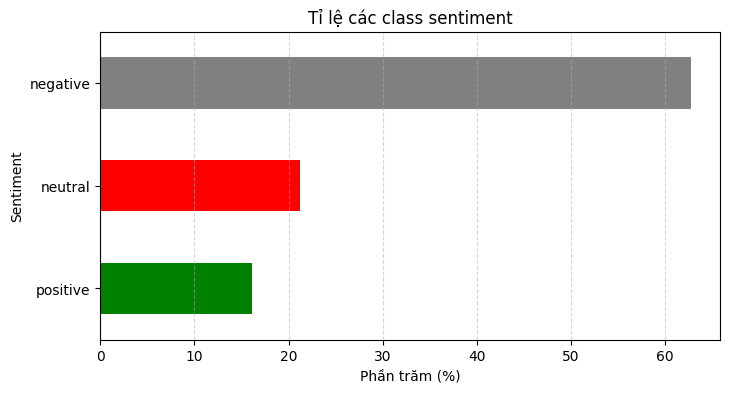

In [ ]:
# Thống kê tỉ lệ dữ liệu giữa các class sentiment:
class_ratio = df['airline_sentiment'].value_counts(normalize=True) * 100
print('Tỉ lệ các class (airline_sentiment):')
print(class_ratio.round(2))

plt.figure(figsize=(8, 4))
class_ratio.sort_values().plot(kind='barh', color=['green', 'red', 'gray'])
plt.title('Tỉ lệ các class sentiment')
plt.xlabel('Phần trăm (%)')
plt.ylabel('Sentiment')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

### top n-grams

In [ ]:

# Top n-grams sau tiền xử lý
def get_ngrams(texts, n=2, top_k=20):
    tokens = []
    for doc in texts:
        if isinstance(doc, str) and doc.strip():
            tokens.extend(doc.split())
    ngrams = Counter([' '.join(tokens[i:i+n]) for i in range(len(tokens)-n+1)])
    return ngrams.most_common(top_k)

for n in (1, 2, 3):
    top_ngrams = get_ngrams(df['text_preprocessed'].fillna(''), n=n, top_k=20)
    print(f"\nTop {n}-grams sau tiền xử lý:")
    for gram, freq in top_ngrams:
        print(f"{gram}: {freq}")



Top 1-grams sau tiền xử lý:
flight: 4671
get: 2103
hour: 1138
thanks: 1068
service: 992
cancel: 963
time: 952
customer: 928
help: 927
delay: 874
call: 774
go: 755
bag: 749
fly: 740
wait: 733
plane: 722
hold: 708
make: 688
need: 683
u: 670

Top 2-grams sau tiền xử lý:
customer service: 564
cancel flightled: 498
flight cancel: 248
late flight: 245
cancel flight: 242
late flightr: 157
fleet fleek: 146
flight delay: 145
flightled flight: 137
flight flight: 136
hold hour: 132
book problem: 124
call back: 113
gate agent: 110
ca get: 106
cancel flighted: 100
flight attendant: 98
get home: 95
flight book: 94
flight get: 88

Top 3-grams sau tiền xử lý:
flight cancel flightled: 163
cancel flightled flight: 134
flight book problem: 74
cancel flight flight: 60
rt fleet fleek: 53
cancel flighted flight: 48
reflight book problem: 46
flight cancel flight: 42
hour late flight: 37
hour late flightr: 36
cancelled flight flight: 33
worst customer service: 29
get cancel flightled: 28
flight cancel flight

## 5. Phát triển: Sentence-BERT + So sánh đánh giá

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix

X = df['light_clean_text'].dropna().tolist()
y = df['airline_sentiment']

# SBERT embedding
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')
X_emb = sbert_model.encode(X, show_progress_bar=True, batch_size=128, device="cpu")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_emb, y, test_size=0.2, random_state=42, stratify=y
)

def eval_and_report(model, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"=== {name} ===")
    print('Macro F1:', f1_score(y_test, y_pred, average='macro'))
    print(classification_report(y_test, y_pred, digits=4))
    print('Confusion matrix:')
    print(confusion_matrix(y_test, y_pred))
    print()

# Logistic Regression + SBERT
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

eval_and_report(lr, 'LogisticRegression + SBERT')

# Random Forest + SBERT
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)

eval_and_report(rf, 'RandomForest + SBERT')

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7123.41it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 115/115 [00:29<00:00,  3.90it/s]


=== LogisticRegression + SBERT ===
Macro F1: 0.7338908954988761
              precision    recall  f1-score   support

    negative     0.9234    0.7755    0.8430      1835
     neutral     0.5528    0.7774    0.6461       620
    positive     0.6835    0.7442    0.7126       473

    accuracy                         0.7708      2928
   macro avg     0.7199    0.7657    0.7339      2928
weighted avg     0.8062    0.7708    0.7802      2928

Confusion matrix:
[[1423  307  105]
 [  80  482   58]
 [  38   83  352]]

=== RandomForest + SBERT ===
Macro F1: 0.5623449255050764
              precision    recall  f1-score   support

    negative     0.7117    0.9875    0.8272      1835
     neutral     0.7881    0.1919    0.3087       620
    positive     0.8398    0.4101    0.5511       473

    accuracy                         0.7258      2928
   macro avg     0.7799    0.5298    0.5623      2928
weighted avg     0.7486    0.7258    0.6728      2928

Confusion matrix:
[[1812   11   12]
 [ 476

=== LogisticRegression + SBERT ===
Macro F1: 0.6876962193806969
              precision    recall  f1-score   support

    negative     0.9051    0.7324    0.8096      1835
     neutral     0.5072    0.7339    0.5999       620
    positive     0.6099    0.7040    0.6536       473

    accuracy                         0.7281      2928
   macro avg     0.6741    0.7234    0.6877      2928
weighted avg     0.7731    0.7281    0.7400      2928

Confusion matrix:
[[1344  350  141]
 [  93  455   72]
 [  48   92  333]]

=== RandomForest + SBERT ===
Macro F1: 0.5147494904041933
              precision    recall  f1-score   support

    negative     0.6900    0.9864    0.8120      1835
     neutral     0.7786    0.1645    0.2716       620
    positive     0.8563    0.3150    0.4606       473

    accuracy                         0.7039      2928
   macro avg     0.7750    0.4886    0.5147      2928
weighted avg     0.7357    0.7039    0.6408      2928

Confusion matrix:
[[1810   18    7]
 [ 500  102   18]
 [ 313   11  149]]


### Giải thích so sánh
- TF-IDF team khác đã thực hiện và dùng n-gram trực tiếp, model dễ interpret bằng hệ số.
- SBERT tạo embedding dense nắm ngữ nghĩa, giúp xóa mờ sự đa dạng cách diễn đạt, phù hợp tweet ngắn có slang/typo.
- Nếu SBERT + model đạt macro F1 cao hơn (đặc biệt với positive/neutral), là bằng chứng nên dùng embedding mạnh.